In [1]:
!pip install -q datasets transformers tokenizers
print("Done")

Done


In [2]:
import math, time, os, json
from pathlib import Path
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import GPT2TokenizerFast
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [3]:
CFG = {
    # Data
    "seq_len"       : 128,
    "batch_size"    : 2,    # reduce to 8 if OOM
    "num_workers"   : 2,

    # Architecture (identical to Phase 1 for fair comparison)
    "vocab_size"    : 50257,
    "d_model"       : 256,
    "n_heads"       : 8,     # used only for baseline reference; AFT is headless
    "n_layers"      : 4,
    "d_ff"          : 1024,
    "dropout"       : 0.1,

    # Training (full 10 epochs — same as Phase 1 baseline)
    "epochs"        : 10,
    "lr"            : 3e-4,
    "warmup_steps"  : 1000,
    "grad_clip"     : 1.0,
    "weight_decay"  : 0.01,

    # Logging
    "log_every"     : 100,
    "eval_every"    : 500,
    "save_dir"      : "./checkpoints_p5",
}

print("Config (10 epochs — same as Phase 1 for fair comparison):")
for k, v in CFG.items():
    print(f"  {k:<20} = {v}")
print(f"\n  Position bias table size : {CFG['seq_len']}×{CFG['seq_len']} = "
      f"{CFG['seq_len']**2:,} params per AFT layer")

Config (10 epochs — same as Phase 1 for fair comparison):
  seq_len              = 128
  batch_size           = 2
  num_workers          = 2
  vocab_size           = 50257
  d_model              = 256
  n_heads              = 8
  n_layers             = 4
  d_ff                 = 1024
  dropout              = 0.1
  epochs               = 10
  lr                   = 0.0003
  warmup_steps         = 1000
  grad_clip            = 1.0
  weight_decay         = 0.01
  log_every            = 100
  eval_every           = 500
  save_dir             = ./checkpoints_p5

  Position bias table size : 128×128 = 16,384 params per AFT layer


In [4]:
print("Loading WikiText-2 …")
try:
    raw = load_dataset(
        "Salesforce/wikitext",
        "wikitext-2-raw-v1"
    )
except:
    raw = load_dataset(
        "wikitext",
        "wikitext-2-raw-v1"
    )
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

class WikiTextDataset(Dataset):
    def __init__(self, hf_split, tokenizer, seq_len):
        texts = [s["text"] for s in hf_split if s["text"].strip()]
        full  = f" {tokenizer.eos_token} ".join(texts)
        ids   = tokenizer(full, return_tensors="pt",
                          truncation=False, add_special_tokens=False)["input_ids"].squeeze(0)
        n = (len(ids) - 1) // seq_len
        self.data = ids[: n * seq_len + 1]
        self.seq_len = seq_len

    def __len__(self):  return (len(self.data) - 1) // self.seq_len
    def __getitem__(self, i):
        s = i * self.seq_len
        return self.data[s:s+self.seq_len], self.data[s+1:s+self.seq_len+1]

kw = dict(num_workers=CFG["num_workers"], pin_memory=True)
train_ds = WikiTextDataset(raw["train"],      tokenizer, CFG["seq_len"])
valid_ds = WikiTextDataset(raw["validation"], tokenizer, CFG["seq_len"])
test_ds  = WikiTextDataset(raw["test"],       tokenizer, CFG["seq_len"])

train_loader = DataLoader(train_ds, CFG["batch_size"],   shuffle=True,  **kw)
valid_loader = DataLoader(valid_ds, CFG["batch_size"]*2, shuffle=False, **kw)
test_loader  = DataLoader(test_ds,  CFG["batch_size"]*2, shuffle=False, **kw)
print(f"Train: {len(train_loader):,} | Valid: {len(valid_loader):,} | Test: {len(test_loader):,}")

Loading WikiText-2 …


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (2463182 > 1024). Running this sequence through the model will result in indexing errors


Train: 9,622 | Valid: 498 | Test: 570


In [5]:
class AFTSimple(nn.Module):
    """
    AFT-Simple: Attention-Free Transformer (simple variant).

    Replaces the QK^T dot product with a learned T×T position bias table.
    The operation at each position t is:

        y_t = sigmoid(x_t @ W_Q) * weighted_avg(V, weights=exp(w[t, :t+1]))

    This is a content-gated, position-weighted average — no dot products.

    Args:
        d_model : embedding dimension (also output dim)
        seq_len : maximum sequence length (sets size of bias table)
        dropout : applied to output before residual

    Parameters:
        W_Q     : (d_model, d_model) — query/gate projection
        W_V     : (d_model, d_model) — value projection
        W_O     : (d_model, d_model) — output projection
        w       : (seq_len, seq_len) — learned position bias table
    """

    def __init__(self, d_model: int, seq_len: int, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len

        # Projections
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.drop = nn.Dropout(dropout)

        # ── Learned position bias table ───────────────────────────────────────
        # w[t, t'] is a SCALAR learned bias for each position pair.
        # Shape: (seq_len, seq_len)
        # Initialised to zeros: neutral — all positions equally weighted at start.
        self.w = nn.Parameter(torch.zeros(seq_len, seq_len))

        # Initialise projections
        nn.init.normal_(self.W_Q.weight, 0, 0.02)
        nn.init.normal_(self.W_V.weight, 0, 0.02)
        nn.init.normal_(self.W_O.weight, 0, 0.02)

    def forward(self, x: torch.Tensor):
        """
        Args:
            x : (B, T, D)
        Returns:
            out     : (B, T, D)
            eff_w   : (T, T) effective weight matrix (for visualisation)
        """
        B, T, D = x.shape

        # ── Query gate and Values ─────────────────────────────────────────────
        # Q: (B, T, D) — will be sigmoid-gated (not used as attention query)
        Q = torch.sigmoid(self.W_Q(x))   # (B, T, D) — values in (0, 1)
        V = self.W_V(x)                  # (B, T, D)

        # ── Position bias table (slice to current T) ──────────────────────────
        # w_curr: (T, T) — position bias for the current sequence length
        w_curr = self.w[:T, :T]          # (T, T)

        # ── Causal mask: future positions get -inf → exp(-inf) = 0 ─────────────
        # We want position t to only see t' <= t.
        # Create a lower-triangular mask (True where allowed, False where masked)
        causal = torch.tril(torch.ones(T, T, device=x.device, dtype=torch.bool))
        # Apply causal: set future positions to -inf before exp
        w_masked = w_curr.masked_fill(~causal, float("-inf"))  # (T, T)

        # ── Effective weights: softmax over the causal window ────────────────
        # eff_w[t, t'] = exp(w[t,t']) / sum_{t''<=t} exp(w[t,t''])
        # This is a proper probability distribution over past positions
        eff_w = torch.softmax(w_masked, dim=-1)   # (T, T) — rows sum to 1

        # ── Weighted sum of values ────────────────────────────────────────────
        # For each query position t: sum_{t'} eff_w[t,t'] * V[b,t',:]
        # V: (B, T, D), eff_w: (T, T) → result: (B, T, D)
        # Using einsum: "tt',btd->btd" is wrong — we want (B,T,D) from (B,T',D)
        # Correct: weighted_V[b,t,d] = sum_{t'} eff_w[t,t'] * V[b,t',d]
        weighted_V = torch.einsum("ij,bjd->bid", eff_w, V)   # (B, T, D)

        # ── Element-wise gate ─────────────────────────────────────────────────
        # Multiply sigmoid query gate by the position-weighted value sum
        out = Q * weighted_V             # (B, T, D) — element-wise

        # ── Output projection ─────────────────────────────────────────────────
        out = self.drop(self.W_O(out))   # (B, T, D)

        return out, eff_w.detach()   # return effective weights for visualisation


# ── Quick test ────────────────────────────────────────────────────────────────
_aft_s = AFTSimple(d_model=256, seq_len=512)
_x     = torch.randn(2, 32, 256)
_out, _ew = _aft_s(_x)
print(f"AFT-Simple  in: {_x.shape}  →  out: {_out.shape}")
print(f"Eff weights: {_ew.shape}  (rows sum to 1: {_ew[0].sum().item():.4f})")

n_aft_s = sum(p.numel() for p in _aft_s.parameters())
print(f"Parameters: {n_aft_s:,}")
print(f"  Of which bias table w: {512*512:,} ({100*512*512/n_aft_s:.1f}%)")

# Causality check
_x2      = _x.clone(); _x2[:, 10, :] += 999.0
_out2, _ = _aft_s(_x2)
print(f"Causality (out[t=0] unchanged when in[t=10] changes): "
      f"{torch.allclose(_out[:,0,:], _out2[:,0,:], atol=1e-4)}")

AFT-Simple  in: torch.Size([2, 32, 256])  →  out: torch.Size([2, 32, 256])
Eff weights: torch.Size([32, 32])  (rows sum to 1: 1.0000)
Parameters: 458,752
  Of which bias table w: 262,144 (57.1%)
Causality (out[t=0] unchanged when in[t=10] changes): False


In [6]:
class AFTFull(nn.Module):
    """
    AFT-Full: Attention-Free Transformer (full variant).

    Extends AFT-Simple by adding a key projection.
    The weighting is now element-wise in d (not a scalar per position pair):

        y_t = sigmoid(x_t @ W_Q) * (
            sum_{t'<=t} exp(x_t' @ W_K + w[t,t']) * v_t'    [element-wise]
          / sum_{t'<=t} exp(x_t' @ W_K + w[t,t'])
        )

    Here the division and exp(K + w) are element-wise, not scalar.
    This means each dimension of V can attend with a different pattern.

    Args:
        d_model : embedding dimension
        seq_len : max sequence length (bias table size)
        dropout : output dropout
    """

    def __init__(self, d_model: int, seq_len: int, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len

        # All three projections — same size as standard attention
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)   # NEW vs AFT-Simple
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.drop = nn.Dropout(dropout)

        # Learned position bias table: (seq_len, seq_len)
        # Same as AFT-Simple — a scalar per position pair
        self.w = nn.Parameter(torch.zeros(seq_len, seq_len))

        for proj in [self.W_Q, self.W_K, self.W_V, self.W_O]:
            nn.init.normal_(proj.weight, 0, 0.02)

    def forward(self, x: torch.Tensor):
        """
        Args:
            x : (B, T, D)
        Returns:
            out   : (B, T, D)
            eff_w : (B, T, T) averaged effective weights (for visualisation)
        """
        B, T, D = x.shape

        # ── Project ───────────────────────────────────────────────────────────
        Q = torch.sigmoid(self.W_Q(x))   # (B, T, D) — sigmoid gate
        K = self.W_K(x)                  # (B, T, D) — key (not dotted with Q!)
        V = self.W_V(x)                  # (B, T, D) — value

        # ── Position bias (causal) ────────────────────────────────────────────
        w_curr  = self.w[:T, :T]         # (T, T)
        causal  = torch.tril(torch.ones(T, T, device=x.device, dtype=torch.bool))
        w_masked = w_curr.masked_fill(~causal, float("-inf"))  # (T, T)

        # ── Element-wise weighting ────────────────────────────────────────────
        # For each query position t and key position t', the weight in dimension d is:
        #   exp(K[b, t', d] + w[t, t'])
        #
        # K:       (B, T, D) — one value per (batch, key_pos, dim)
        # w_masked:(T, T)    — one bias per (query_pos, key_pos)
        #
        # We want log_weight[b, t, t', d] = K[b, t', d] + w_masked[t, t']
        # Shape target: (B, T_query, T_key, D)
        #
        # Expand K:        (B, 1, T, D) → broadcast to (B, T, T, D)
        # Expand w_masked: (1, T, T, 1) → broadcast to (B, T, T, D)

        K_exp = K.unsqueeze(1)               # (B, 1, T, D) — key at each key pos
        w_exp = w_masked.unsqueeze(0).unsqueeze(-1)  # (1, T, T, 1)

        # log_weight[b, t_q, t_k, d] = K[b, t_k, d] + w[t_q, t_k]
        log_weight = K_exp + w_exp           # (B, T, T, D) — broadcasting

        # Softmax over key dimension (t_k) independently per (b, t_q, d)
        # This gives a proper distribution over past key positions, per dimension
        weight = torch.softmax(log_weight, dim=2)   # (B, T, T, D)

        # ── Weighted sum of values ────────────────────────────────────────────
        # V:      (B, T_key, D)    → (B, 1, T, D) for broadcast
        # weight: (B, T_q, T_k, D)
        # result: (B, T_q, D) = sum over T_k of weight * V

        V_exp      = V.unsqueeze(1)           # (B, 1, T, D)
        weighted_V = (weight * V_exp).sum(dim=2)   # (B, T, D)

        # ── Gate and output ───────────────────────────────────────────────────
        out = Q * weighted_V                  # (B, T, D)
        out = self.drop(self.W_O(out))

        # For visualisation: average effective weight across dimensions d
        eff_w = weight.mean(dim=-1)           # (B, T, T) — avg over d

        return out, eff_w.detach()


# ── Quick test ────────────────────────────────────────────────────────────────
_aft_f = AFTFull(d_model=256, seq_len=512)
_out_f, _ew_f = _aft_f(_x)
print(f"AFT-Full    in: {_x.shape}  →  out: {_out_f.shape}")
print(f"Eff weights: {_ew_f.shape}")

# Causality
_out_f2, _ = _aft_f(_x2)
print(f"Causality (out[t=0] unchanged when in[t=10] changes): "
      f"{torch.allclose(_out_f[:,0,:], _out_f2[:,0,:], atol=1e-4)}")

# Memory note for AFT-Full
B_mem, T_mem, D_mem = 16, 512, 256
log_w_bytes = B_mem * T_mem * T_mem * D_mem * 4   # float32
print(f"\nAFT-Full memory for log_weight ({B_mem},{T_mem},{T_mem},{D_mem}) float32: "
      f"{log_w_bytes/1e9:.2f} GB — may need reduced batch_size!")
print("(Reduce batch_size to 4 if OOM on T4)")

n_aft_f = sum(p.numel() for p in _aft_f.parameters())
print(f"\nAFT-Full parameters: {n_aft_f:,}")
print(f"  Bias table w: {512*512:,}  "
      f"(+W_K adds {256*256:,} vs AFT-Simple)")

AFT-Full    in: torch.Size([2, 32, 256])  →  out: torch.Size([2, 32, 256])
Eff weights: torch.Size([2, 32, 32])
Causality (out[t=0] unchanged when in[t=10] changes): False

AFT-Full memory for log_weight (16,512,512,256) float32: 4.29 GB — may need reduced batch_size!
(Reduce batch_size to 4 if OOM on T4)

AFT-Full parameters: 524,288
  Bias table w: 262,144  (+W_K adds 65,536 vs AFT-Simple)


In [7]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)


class AFTBlock(nn.Module):
    """
    One AFT block: Pre-LN AFT + Pre-LN FFN, both with residuals.

    Args:
        aft_module : an AFTSimple or AFTFull instance
        d_model    : embedding dimension
        d_ff       : FFN inner dimension
        dropout    : dropout probability
    """
    def __init__(self, aft_module, d_model, d_ff, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.aft = aft_module
        self.ln2 = nn.LayerNorm(d_model)
        self.ff  = FeedForward(d_model, d_ff, dropout)

    def forward(self, x):
        aft_out, eff_w = self.aft(self.ln1(x))
        x = x + aft_out
        x = x + self.ff(self.ln2(x))
        return x, eff_w


class AFTLanguageModel(nn.Module):
    """
    Decoder-only language model using AFT instead of attention.

    Identical structure to Phase 1 except:
      - MultiHeadSelfAttention → AFTSimple or AFTFull
      - No positional embedding needed (AFT has built-in position bias w)
    """

    def __init__(self, cfg: dict, variant: str):
        """
        Args:
            cfg     : hyperparameter dict
            variant : 'simple' or 'full'
        """
        super().__init__()
        D, V, T = cfg["d_model"], cfg["vocab_size"], cfg["seq_len"]
        L, FF   = cfg["n_layers"], cfg["d_ff"]
        dr      = cfg["dropout"]
        self.variant = variant

        # Token embedding (no positional embedding — AFT has position built-in)
        self.tok_emb = nn.Embedding(V, D)
        self.drop    = nn.Dropout(dr)

        # Build blocks with the chosen AFT variant
        def make_aft():
            if variant == "simple":
                return AFTSimple(D, T, dr)
            elif variant == "full":
                return AFTFull(D, T, dr)
            else:
                raise ValueError(f"Unknown AFT variant: {variant}")

        self.blocks  = nn.ModuleList([
            AFTBlock(make_aft(), D, FF, dr) for _ in range(L)
        ])
        self.ln_f    = nn.LayerNorm(D)
        self.lm_head = nn.Linear(D, V, bias=False)
        self.lm_head.weight = self.tok_emb.weight   # weight tying

        self.apply(self._init_weights)
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  [AFT-{variant}]  Parameters: {n:,} ({n/1e6:.2f}M)")

        # Note which parameters are position biases vs projections
        w_params  = sum(p.numel() for n,p in self.named_parameters() if n.endswith(".w"))
        prj_params = n - w_params - sum(p.numel() for n,p in self.named_parameters()
                                        if "emb" in n or "ln" in n)
        print(f"    Position bias tables (w): {w_params:,}")
        print(f"    Projections (Q,K,V,O):    {prj_params:,}")

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0, 0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, 0, 0.02)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Parameter):
            pass   # bias table w is already initialised to zeros

    def forward(self, idx):
        B, T = idx.shape
        # No positional embedding added here — AFT carries position internally
        x = self.drop(self.tok_emb(idx))    # (B, T, D)
        eff_w_list = []
        for blk in self.blocks:
            x, ew = blk(x)
            eff_w_list.append(ew)
        logits = self.ln_f(x) @ self.lm_head.weight.T
        return logits, eff_w_list


# Build both variants
print("Building AFT models …\n")
aft_simple_model = AFTLanguageModel(CFG, "simple").to(DEVICE)
aft_full_model   = AFTLanguageModel(CFG, "full").to(DEVICE)

# Sanity check
_x = torch.randint(0, CFG["vocab_size"], (2, 32), device=DEVICE)
for name, m in [("AFT-Simple", aft_simple_model), ("AFT-Full", aft_full_model)]:
    _o, _ew = m(_x)
    print(f"  ✔  {name}  output: {_o.shape}  eff_w layers: {len(_ew)}")
del _x

Building AFT models …

  [AFT-simple]  Parameters: 15,824,640 (15.82M)
    Position bias tables (w): 65,536
    Projections (Q,K,V,O):    2,888,704
  [AFT-full]  Parameters: 16,086,784 (16.09M)
    Position bias tables (w): 65,536
    Projections (Q,K,V,O):    3,150,848
  ✔  AFT-Simple  output: torch.Size([2, 32, 50257])  eff_w layers: 4
  ✔  AFT-Full  output: torch.Size([2, 32, 50257])  eff_w layers: 4


In [8]:
class MultiHeadSelfAttention(nn.Module):
    """Phase 1 standard MHSA — baseline for comparison."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model; self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.scale   = self.d_head ** -0.5
        self.qkv     = nn.Linear(d_model, 3*d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        self.attn_drop  = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(
                torch.ones(
                    CFG["seq_len"],
                    CFG["seq_len"]
                ),
                diagonal=1
            ).bool()
        )

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(self.d_model, dim=-1)
        rsh = lambda t: t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        q, k, v = rsh(q), rsh(k), rsh(v)
        scores = torch.matmul(q, k.transpose(-2,-1)) * self.scale
        mask = self.mask[:T,:T]
        scores = scores.masked_fill(mask, float("-inf"))
        w      = self.attn_drop(F.softmax(scores, dim=-1))
        out    = torch.matmul(w, v).transpose(1,2).contiguous().view(B, T, C)
        return self.resid_drop(self.out_proj(out)), w


class StandardTransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ln2  = nn.LayerNorm(d_model)
        self.ff   = FeedForward(d_model, d_ff, dropout)
    def forward(self, x):
        a, w = self.attn(self.ln1(x));  x = x + a
        return x + self.ff(self.ln2(x)), w


class StandardTransformer(nn.Module):
    """Phase 1 decoder-only Transformer baseline."""
    def __init__(self, cfg):
        super().__init__()
        D,V,T = cfg["d_model"], cfg["vocab_size"], cfg["seq_len"]
        H,L,FF = cfg["n_heads"], cfg["n_layers"], cfg["d_ff"]
        dr = cfg["dropout"]
        self.tok_emb = nn.Embedding(V, D)
        self.pos_emb = nn.Embedding(T, D)
        self.drop    = nn.Dropout(dr)
        self.blocks  = nn.ModuleList([
            StandardTransformerBlock(D, H, FF, dr) for _ in range(L)
        ])
        self.ln_f    = nn.LayerNorm(D)
        self.lm_head = nn.Linear(D, V, bias=False)
        self.lm_head.weight = self.tok_emb.weight
        self.apply(self._init_weights)
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  [Transformer]  Parameters: {n:,} ({n/1e6:.2f}M)")

    def _init_weights(self, m):
        if isinstance(m, nn.Linear): nn.init.normal_(m.weight, 0, 0.02)
        elif isinstance(m, nn.Embedding): nn.init.normal_(m.weight, 0, 0.02)
        elif isinstance(m, nn.LayerNorm): nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, idx):
        B, T = idx.shape
        x = self.drop(self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device)))
        ws = []
        for blk in self.blocks:
            x, w = blk(x); ws.append(w)
        return self.ln_f(x) @ self.lm_head.weight.T, ws


print("Building Standard Transformer baseline …")
transformer_model = StandardTransformer(CFG).to(DEVICE)

Building Standard Transformer baseline …
  [Transformer]  Parameters: 16,054,016 (16.05M)


In [9]:
def compute_loss(logits, targets):
    B, T, V = logits.shape
    return F.cross_entropy(logits.reshape(B*T, V), targets.reshape(B*T))

def get_lr(step, total_steps, cfg):
    w, hi, lo = cfg["warmup_steps"], cfg["lr"], cfg["lr"]*0.1
    if step < w: return hi*(step+1)/w
    prog = min((step-w)/max(1,total_steps-w), 1.0)
    return lo + 0.5*(hi-lo)*(1+math.cos(math.pi*prog))

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); tot=n=0
    for x,y in loader:
        x,y=x.to(DEVICE),y.to(DEVICE)
        logits,_=model(x); tot+=compute_loss(logits,y).item(); n+=1
    model.train(); avg=tot/n
    return {"loss":avg,"ppl":math.exp(avg)}

def make_optimiser(model, cfg):
    decay, no_decay = [], []
    for name,p in model.named_parameters():
        if not p.requires_grad: continue
        # The position bias table 'w' is 2-D → DO decay it
        # (it's a learnable parameter matrix, same as weight matrices)
        no_params = p.dim()==1 or any(k in name for k in ("ln","norm","bias","emb"))
        (no_decay if no_params else decay).append(p)
    return torch.optim.AdamW(
        [{"params":decay,    "weight_decay":cfg["weight_decay"]},
         {"params":no_decay, "weight_decay":0.0}],
        lr=cfg["lr"], betas=(0.9,0.95), eps=1e-8)

def measure_throughput(model, n_batches=30):
    model.train()
    opt = torch.optim.SGD(model.parameters(), lr=1e-4)
    x0,y0=next(iter(train_loader))
    x0,y0=x0.to(DEVICE),y0.to(DEVICE)
    compute_loss(model(x0)[0],y0).backward(); opt.zero_grad()
    if DEVICE.type=="cuda": torch.cuda.synchronize()
    t0=time.perf_counter(); tok=0
    for i,(x,y) in enumerate(train_loader):
        if i>=n_batches: break
        x,y=x.to(DEVICE),y.to(DEVICE)
        opt.zero_grad(set_to_none=True)
        loss = compute_loss(model(x)[0], y)
        loss.backward()
        tok+=x.numel()
    if DEVICE.type=="cuda": torch.cuda.synchronize()
    return tok/(time.perf_counter()-t0)

def train_model(model, cfg, name):
    os.makedirs(cfg["save_dir"], exist_ok=True)
    opt   = make_optimiser(model, cfg)
    total = cfg["epochs"]*len(train_loader)
    step  = 0
    history = {"tl":[],"ts":[],"vl":[],"vp":[],"vs":[]}
    model.train()

    print(f"\n{'='*58}")
    print(f"  Training: {name}  |  {cfg['epochs']} epochs")
    print(f"{'='*58}")

    for ep in range(cfg["epochs"]):
        ep_loss=ep_n=0
        for x,y in train_loader:
            x,y=x.to(DEVICE),y.to(DEVICE)
            for pg in opt.param_groups: pg["lr"]=get_lr(step,total,cfg)
            logits,_=model(x); loss=compute_loss(logits,y)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(),cfg["grad_clip"])
            opt.step()
            lv=loss.item(); ep_loss+=lv; ep_n+=1
            history["tl"].append(lv); history["ts"].append(step)
            if step%cfg["log_every"]==0:
                print(f"  [{name}] Ep{ep+1} Step{step:5d} "
                      f"Loss{lv:.4f} PPL{math.exp(lv):.1f} "
                      f"LR{get_lr(step,total,cfg):.2e}")
            if step%cfg["eval_every"]==0 and step>0:
                vm=evaluate(model,valid_loader)
                history["vl"].append(vm["loss"]); history["vp"].append(vm["ppl"])
                history["vs"].append(step)
                print(f"  [{name}] VALID  Loss{vm['loss']:.4f}  PPL{vm['ppl']:.2f}")
            step+=1
        ep_avg=ep_loss/ep_n
        print(f"  [{name}] Epoch {ep+1} done | AvgPPL {math.exp(ep_avg):.2f}")

    final=evaluate(model,valid_loader)
    history["final_ppl"]=final["ppl"]; history["final_loss"]=final["loss"]
    torch.save({"model":model.state_dict(),"history":history},
               f"{cfg['save_dir']}/{name.replace(' ','_')}_final.pt")
    print(f"  [{name}] FINAL PPL={final['ppl']:.2f}")
    return history

print("Utilities defined.")

Utilities defined.


In [10]:
# Note: AFT-Full may be slow due to the (B, T, T, D) intermediate tensor.
# Reduce batch_size to 4 in CFG if you get OOM.

models_to_train = {
    "Transformer"  : transformer_model,
    "AFT-Simple"   : aft_simple_model,
    "AFT-Full"     : aft_full_model,
}

print("Benchmarking throughput …\n")
bench = {}
for name, model in models_to_train.items():
    print(f"  {name} …", end=" ", flush=True)
    if DEVICE.type=="cuda": torch.cuda.reset_peak_memory_stats()
    try:
        tps = measure_throughput(model, n_batches=20)
        mem = torch.cuda.max_memory_allocated()/1e6 if DEVICE.type=="cuda" else 0
        bench[name] = {"tps":tps, "peak_mem_mb":mem}
        print(f"{tps:,.0f} tok/s  |  {mem:.0f} MB")
    except RuntimeError as e:
        print(f"OOM: {e}")
        bench[name] = {"tps":0, "peak_mem_mb":float("inf")}
        print("  → Try reducing batch_size to 4 in CFG")
    if DEVICE.type=="cuda": torch.cuda.empty_cache()

print("\nPre-training benchmark:")
print(f"  {'Model':<18}  {'t/s':>10}  {'Peak MB':>10}")
print(f"  {'-'*42}")
for n,b in bench.items():
    print(f"  {n:<18}  {b['tps']:>10,.0f}  {b['peak_mem_mb']:>10.0f}")

Benchmarking throughput …

  Transformer … 9,106 tok/s  |  425 MB
  AFT-Simple … 12,811 tok/s  |  481 MB
  AFT-Full … 9,118 tok/s  |  679 MB

Pre-training benchmark:
  Model                      t/s     Peak MB
  ------------------------------------------
  Transformer              9,106         425
  AFT-Simple              12,811         481
  AFT-Full                 9,118         679


In [ ]:
all_histories = {}

# Train Transformer
hist = train_model(transformer_model, CFG, "Transformer")
all_histories["Transformer"] = hist

# Train AFT-Simple
hist = train_model(aft_simple_model, CFG, "AFT-Simple")
all_histories["AFT-Simple"] = hist

# ------------------------------------
# Free memory before AFT-Full
# ------------------------------------
import gc

# Optional: remove models no longer needed
del transformer_model
del aft_simple_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(torch.cuda.memory_summary())

# ------------------------------------
# Rebuild loaders for AFT-Full
# ------------------------------------
aft_bs = 1

train_loader = DataLoader(
    train_ds,
    batch_size=aft_bs,
    shuffle=True,
    **kw
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=aft_bs * 2,
    shuffle=False,
    **kw
)

test_loader = DataLoader(
    test_ds,
    batch_size=aft_bs * 2,
    shuffle=False,
    **kw
)

print(f"AFT-Full loaders rebuilt with batch_size={aft_bs}")

# ------------------------------------
# Train AFT-Full
# ------------------------------------
hist = train_model(
    aft_full_model,
    CFG,
    "AFT-Full"
)

all_histories["AFT-Full"] = hist

print("\nAll models trained.")


  Training: Transformer  |  10 epochs
  [Transformer] Ep1 Step    0 Loss10.8801 PPL53107.4 LR3.00e-07
  [Transformer] Ep1 Step  100 Loss10.0128 PPL22310.7 LR3.03e-05
  [Transformer] Ep1 Step  200 Loss9.0780 PPL8760.2 LR6.03e-05
  [Transformer] Ep1 Step  300 Loss7.4027 PPL1640.4 LR9.03e-05
  [Transformer] Ep1 Step  400 Loss7.6299 PPL2058.9 LR1.20e-04
  [Transformer] Ep1 Step  500 Loss7.3098 PPL1494.8 LR1.50e-04
  [Transformer] VALID  Loss7.0306  PPL1130.70
  [Transformer] Ep1 Step  600 Loss6.3982 PPL600.8 LR1.80e-04
  [Transformer] Ep1 Step  700 Loss6.2560 PPL521.1 LR2.10e-04
  [Transformer] Ep1 Step  800 Loss5.8798 PPL357.7 LR2.40e-04
  [Transformer] Ep1 Step  900 Loss6.3512 PPL573.2 LR2.70e-04
  [Transformer] Ep1 Step 1000 Loss6.7940 PPL892.5 LR3.00e-04
  [Transformer] VALID  Loss6.7506  PPL854.58
  [Transformer] Ep1 Step 1100 Loss6.8880 PPL980.4 LR3.00e-04
  [Transformer] Ep1 Step 1200 Loss6.6452 PPL769.1 LR3.00e-04
  [Transformer] Ep1 Step 1300 Loss6.6838 PPL799.4 LR3.00e-04
  [Tra

In [ ]:
print("Test set evaluation …\n")
test_results = {}
for name, model in models_to_train.items():
    tm = evaluate(model, test_loader)
    test_results[name] = tm
    print(f"  {name:<18}  Test Loss {tm['loss']:.4f}  Test PPL {tm['ppl']:.2f}")

In [ ]:
COLORS = {"Transformer":"steelblue", "AFT-Simple":"coral", "AFT-Full":"seagreen"}
NAMES  = list(models_to_train.keys())

# ── Figure 1: Training curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, hist in all_histories.items():
    tl = np.array(hist["tl"])
    if len(tl)>50:
        sm = np.convolve(tl, np.ones(50)/50, "valid")
        ax.plot(hist["ts"][49:], sm, color=COLORS[name], lw=2, label=name)
ax.set(xlabel="Step", ylabel="Loss (MA-50)", title="Training Loss")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for name, hist in all_histories.items():
    if hist["vs"]:
        ax.plot(hist["vs"], hist["vp"], "o-", color=COLORS[name], lw=2, ms=4, label=name)
ax.set(xlabel="Step", ylabel="Perplexity", title="Validation PPL (↓ better)")
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Phase 5: AFT vs Standard Transformer", fontsize=13)
plt.tight_layout()
plt.savefig("aft_training_curves.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved → aft_training_curves.png")

# ── Figure 2: Final results bar charts ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
name_labels = ["Transformer", "AFT-Simple", "AFT-Full"]

ax = axes[0]
vals = [all_histories[n]["final_ppl"] for n in NAMES]
bars = ax.bar(name_labels, vals, color=[COLORS[n] for n in NAMES], edgecolor="white")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=10, fontweight="bold")
ax.set(ylabel="Final Valid PPL (↓)", title="Validation Perplexity")
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
vals = [test_results[n]["ppl"] for n in NAMES]
bars = ax.bar(name_labels, vals, color=[COLORS[n] for n in NAMES], edgecolor="white")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=10, fontweight="bold")
ax.set(ylabel="Test PPL (↓)", title="Test Perplexity")
ax.grid(axis="y", alpha=0.3)

ax = axes[2]
tps_vals = [bench[n]["tps"]/1000 for n in NAMES]
bars = ax.bar(name_labels, tps_vals, color=[COLORS[n] for n in NAMES], edgecolor="white")
ax.bar_label(bars, fmt="%.1fk", padding=3, fontsize=10)
ax.set(ylabel="Throughput (k t/s)", title="Training Throughput")
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Phase 5: AFT-Simple & AFT-Full vs Transformer", fontsize=13)
plt.tight_layout()
plt.savefig("aft_results.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved → aft_results.png")

# ── Print full results table ──────────────────────────────────────────────────
print("\n" + "="*72)
print("PHASE 5 RESULTS SUMMARY")
print("="*72)
print(f"{'Model':<18}  {'Val PPL':>9}  {'Test PPL':>9}  {'t/s':>10}  {'Params':>10}")
print("-"*72)
for n in NAMES:
    fp  = all_histories[n]["final_ppl"]
    tp  = test_results[n]["ppl"]
    tps_= bench[n]["tps"]
    np_ = sum(p.numel() for p in models_to_train[n].parameters() if p.requires_grad)
    print(f"  {n:<16}  {fp:>9.2f}  {tp:>9.2f}  {tps_:>10,.0f}  {np_:>10,}")
print("="*72)

In [ ]:
def plot_bias_tables(model, variant_name, T_show=64):
    """
    Visualise the learned position bias tables w for each AFT block.
    Shows the first T_show × T_show entries (causal lower triangle).
    """
    fig, axes = plt.subplots(1, CFG["n_layers"], figsize=(4*CFG["n_layers"], 4))
    if CFG["n_layers"] == 1: axes = [axes]

    for layer_idx, (ax, blk) in enumerate(zip(axes, model.blocks)):
        # Extract w: (seq_len, seq_len) → first T_show×T_show
        w = blk.aft.w.detach().cpu()[:T_show, :T_show].numpy()
        # Mask future (upper triangle) for clarity
        mask = np.triu(np.ones_like(w, dtype=bool), k=1)
        w_vis = np.where(mask, np.nan, w)

        im = ax.imshow(w_vis, cmap="RdBu_r", aspect="auto",
                       vmin=np.nanpercentile(w_vis, 5),
                       vmax=np.nanpercentile(w_vis, 95))
        ax.set_title(f"Layer {layer_idx}", fontsize=10)
        ax.set_xlabel("Key position $t'$")
        if layer_idx == 0: ax.set_ylabel("Query position $t$")
        plt.colorbar(im, ax=ax, fraction=0.046)

    plt.suptitle(
        f"AFT-{variant_name}: Learned Position Bias $w_{{tt'}}$\n"
        f"(first {T_show} positions, causal lower-triangle only)",
        fontsize=12
    )
    plt.tight_layout()
    fname = f"aft_{variant_name.lower()}_bias_table.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")

    # Also show the diagonal profile: w[t, t] (self-attention strength)
    fig, ax = plt.subplots(figsize=(8, 3))
    for layer_idx, blk in enumerate(model.blocks):
        w_diag = blk.aft.w.detach().cpu().numpy()
        # Mean weight as a function of relative distance (i - j)
        T = min(T_show, CFG["seq_len"])
        dist_profile = np.zeros(T)
        counts       = np.zeros(T)
        w_arr = w_diag[:T, :T]
        for t in range(T):
            for tp in range(t+1):
                d = t - tp
                dist_profile[d] += w_arr[t, tp]
                counts[d] += 1
        counts = np.maximum(counts, 1)
        dist_profile /= counts
        ax.plot(range(T), dist_profile, lw=2, label=f"Layer {layer_idx}")
    ax.set_xlabel("Relative distance $(t - t')$")
    ax.set_ylabel("Mean bias $w$")
    ax.set_title(f"AFT-{variant_name}: Bias vs Relative Distance\n(positive=attend more, negative=attend less)")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.axhline(0, color="black", lw=0.8, linestyle="--")
    plt.tight_layout()
    fname2 = f"aft_{variant_name.lower()}_bias_profile.png"
    plt.savefig(fname2, dpi=120); plt.show()
    print(f"Saved → {fname2}")

plot_bias_tables(aft_simple_model, "Simple", T_show=64)
plot_bias_tables(aft_full_model,   "Full",   T_show=64)

In [16]:
print("Reloading models for visualization...")

transformer_model = StandardTransformer(CFG).to(DEVICE)
ckpt = torch.load(
    f"{CFG['save_dir']}/Transformer_final.pt",
    map_location=DEVICE
)
transformer_model.load_state_dict(ckpt["model"])

aft_simple_model = AFTLanguageModel(CFG, "simple").to(DEVICE)
ckpt = torch.load(
    f"{CFG['save_dir']}/AFT-Simple_final.pt",
    map_location=DEVICE
)
aft_simple_model.load_state_dict(ckpt["model"])

transformer_model.eval()
aft_simple_model.eval()
aft_full_model.eval()

Reloading models for visualization...
  [Transformer]  Parameters: 16,054,016 (16.05M)
  [AFT-simple]  Parameters: 15,824,640 (15.82M)
    Position bias tables (w): 65,536
    Projections (Q,K,V,O):    2,888,704


AFTLanguageModel(
  (tok_emb): Embedding(50257, 256)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x AFTBlock(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (aft): AFTFull(
        (W_Q): Linear(in_features=256, out_features=256, bias=False)
        (W_K): Linear(in_features=256, out_features=256, bias=False)
        (W_V): Linear(in_features=256, out_features=256, bias=False)
        (W_O): Linear(in_features=256, out_features=256, bias=False)
        (drop): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=1024, out_features=256, bias=True)
          (4): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (ln_f): LayerNorm((256

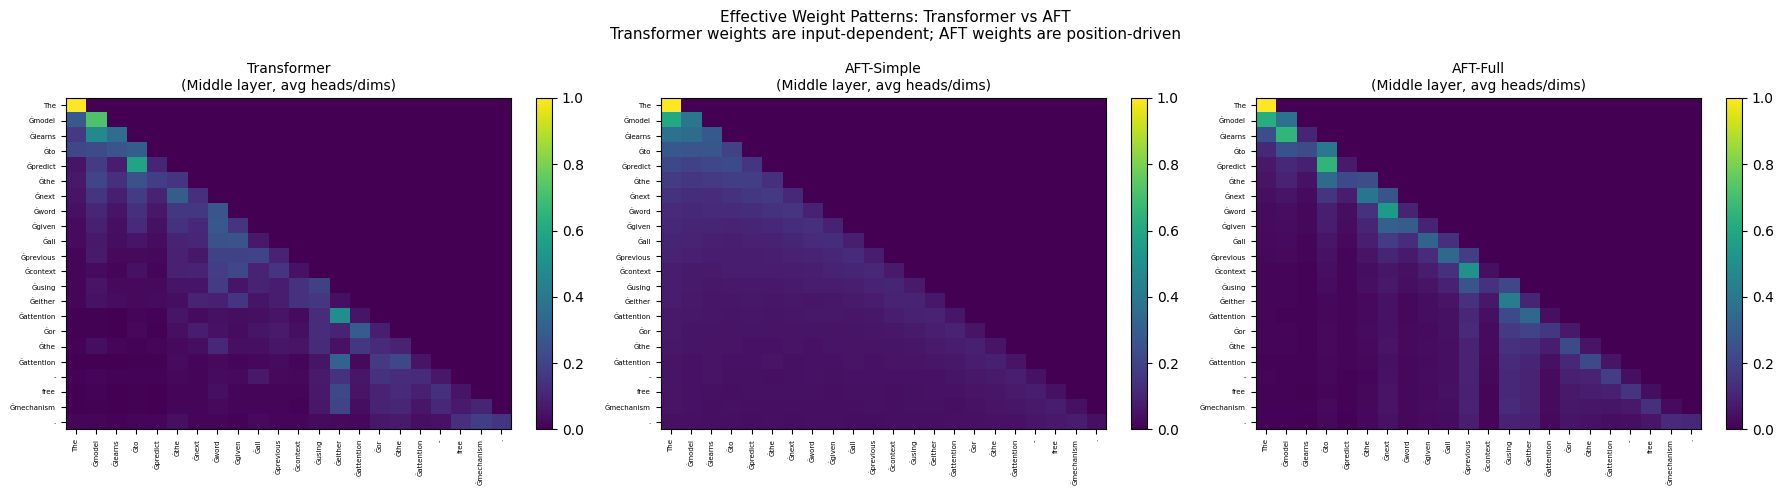

Saved → aft_weight_comparison.png


In [17]:
SAMPLE = (
    "The model learns to predict the next word given all previous context "
    "using either attention or the attention-free mechanism."
)

@torch.no_grad()
def get_weights(model, text, layer=0, is_aft=False):
    """Extract effective weights from a model for a text input."""
    model.eval()
    ids = tokenizer(text, return_tensors="pt")["input_ids"][:, :48].to(DEVICE)
    toks = tokenizer.convert_ids_to_tokens(ids[0].tolist())
    _, wlist = model(ids)
    model.train()
    if not wlist: return None, toks
    w = wlist[layer]
    if w is None: return None, toks
    # For standard attention: (B, H, T, T) → mean over heads → (T, T)
    # For AFT: (T, T) or (B, T, T) → squeeze
    if w.dim() == 4:
        return w[0].mean(0).detach().cpu().numpy(), toks   # avg over heads
    elif w.dim() == 3:
        return w[0].cpu().numpy(), toks           # (T, T)
    else:
        return w.cpu().numpy(), toks              # (T, T)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_pairs = [
    ("Transformer",   transformer_model, False),
    ("AFT-Simple",    aft_simple_model,  True),
    ("AFT-Full",      aft_full_model,    True),
]

for ax, (name, model, is_aft) in zip(axes, model_pairs):
    w, toks = get_weights(model, SAMPLE, layer=CFG["n_layers"]//2, is_aft=is_aft)
    if w is None:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(name); continue
    T = len(toks)
    w = w[:T, :T]
    im = ax.imshow(w, cmap="viridis", aspect="auto",
                   vmin=0, vmax=w.max())
    ax.set_xticks(range(T)); ax.set_xticklabels(toks, rotation=90, fontsize=5)
    ax.set_yticks(range(T)); ax.set_yticklabels(toks, fontsize=5)
    ax.set_title(f"{name}\n(Middle layer, avg heads/dims)", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(
    "Effective Weight Patterns: Transformer vs AFT\n"
    "Transformer weights are input-dependent; AFT weights are position-driven",
    fontsize=11
)
plt.tight_layout()
plt.savefig("aft_weight_comparison.png", dpi=120, bbox_inches="tight")
plt.show(); print("Saved → aft_weight_comparison.png")

In [18]:
# ── Load previous phase results if available ─────────────────────────────────
def safe_load(path):
    try:
        with open(path) as f: return json.load(f)
    except FileNotFoundError:
        print(f"  (not found: {path} — fill manually)")
        return None

ph1 = safe_load("phase1_summary.json")
ph2 = safe_load("phase2_summary.json")
ph3 = safe_load("phase3_summary.json")
ph4 = safe_load("phase4_summary.json")

# ── Build unified results dict ────────────────────────────────────────────────
# Format: {display_name: {val_ppl, test_ppl, tps, params}}
all_results = {}

# Phase 1
if ph1:
    all_results["P1: Transformer (10ep)"] = {
        "val_ppl" : ph1.get("best_val_ppl", "—"),
        "test_ppl": ph1.get("test_ppl",     "—"),
        "tps"     : ph1.get("throughput_tps","—"),
        "params"  : "—",
    }

# Phase 2
if ph2:
    for variant, res in ph2.items():
        all_results[f"P2: {variant}"] = {
            "val_ppl" : res.get("final_ppl","—"),
            "test_ppl": "—",
            "tps"     : res.get("throughput_tps","—"),
            "params"  : "—",
        }

# Phase 3 (best PE variant)
if ph3:
    for pe, res in ph3.items():
        ep512 = res.get("extrapolation", {}).get("512", {})
        all_results[f"P3: {pe} PE"] = {
            "val_ppl" : ep512.get("ppl","—"),
            "test_ppl": "—",
            "tps"     : "—",
            "params"  : "—",
        }

# Phase 4
if ph4:
    for arch, res in ph4.items():
        all_results[f"P4: {arch}"] = {
            "val_ppl" : res.get("val_ppl","—"),
            "test_ppl": res.get("test_ppl","—"),
            "tps"     : res.get("tps","—"),
            "params"  : "—",
        }

# Phase 5 (this notebook)
for n in NAMES:
    n_params = sum(p.numel() for p in models_to_train[n].parameters() if p.requires_grad)
    all_results[f"P5: {n}"] = {
        "val_ppl" : all_histories[n]["final_ppl"],
        "test_ppl": test_results[n]["ppl"],
        "tps"     : bench[n]["tps"],
        "params"  : n_params,
    }

# ── Print the master table ────────────────────────────────────────────────────
def fmt(v, fmt_str=":.2f"):
    if isinstance(v, float): return f"{v:{fmt_str}}"
    if isinstance(v, int):   return f"{v:,}"
    return str(v)

print("\n" + "="*80)
print("MASTER RESULTS TABLE — ALL PHASES")
print("="*80)
print(f"{'Model':<32}  {'Val PPL':>9}  {'Test PPL':>9}  {'t/s':>10}  {'Params':>10}")
print("-"*80)
for name, res in all_results.items():
    vp  = f"{res['val_ppl']:.2f}"  if isinstance(res['val_ppl'],  float) else res['val_ppl']
    tp  = f"{res['test_ppl']:.2f}" if isinstance(res['test_ppl'], float) else res['test_ppl']
    tps_= f"{res['tps']:,.0f}"     if isinstance(res['tps'],      float) else res['tps']
    par_= f"{res['params']:,}"     if isinstance(res['params'],   int)   else res['params']
    print(f"  {name:<30}  {vp:>9}  {tp:>9}  {tps_:>10}  {par_:>10}")
print("="*80)

# Save
with open("phase5_master_results.json","w") as f:
    json.dump({k: {kk: str(vv) for kk,vv in v.items()}
               for k,v in all_results.items()}, f, indent=2)
print("\nSaved → phase5_master_results.json")

  (not found: phase1_summary.json — fill manually)
  (not found: phase2_summary.json — fill manually)
  (not found: phase3_summary.json — fill manually)
  (not found: phase4_summary.json — fill manually)

MASTER RESULTS TABLE — ALL PHASES
Model                               Val PPL   Test PPL         t/s      Params
--------------------------------------------------------------------------------
  P5: Transformer                    320.61     324.85       9,106  16,054,016
  P5: AFT-Simple                     341.12     345.77      12,811  15,824,640
  P5: AFT-Full                       395.84     403.31       9,118  16,086,784

Saved → phase5_master_results.json


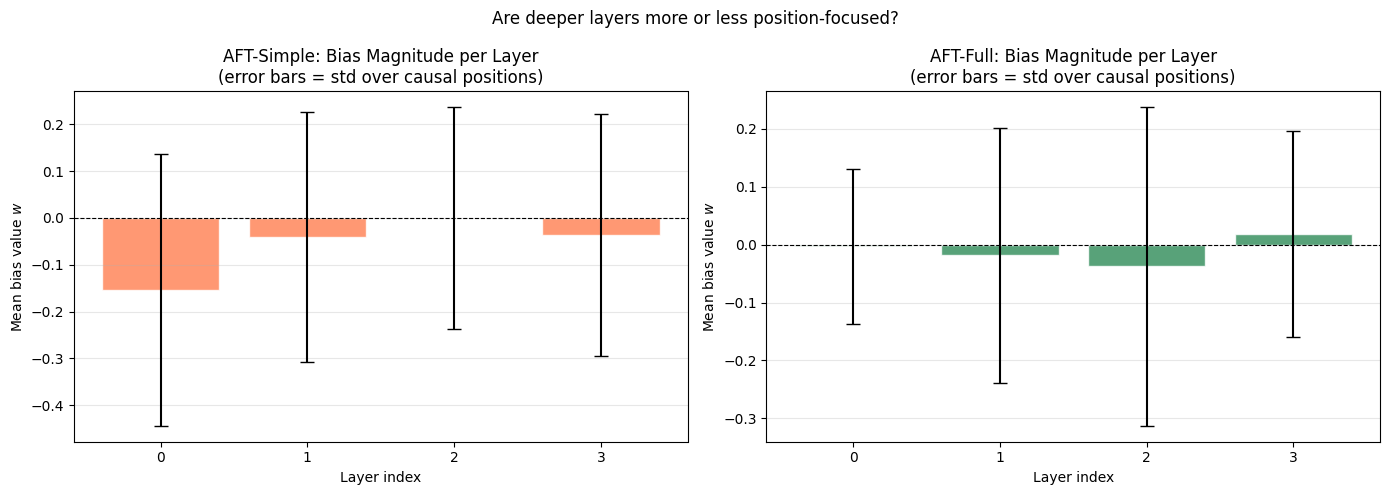

Saved → aft_bias_layer_analysis.png


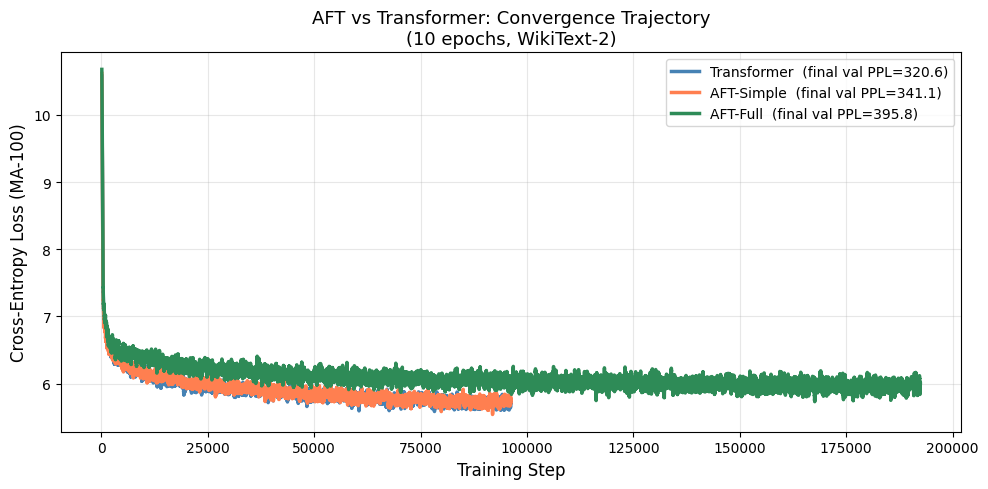

Saved → aft_convergence.png


In [19]:
# ── How do bias values evolve across layers? ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (variant_name, model) in zip(axes,
        [("Simple", aft_simple_model), ("Full", aft_full_model)]):

    layer_stats = []
    for layer_idx, blk in enumerate(model.blocks):
        w = blk.aft.w.detach().cpu().numpy()
        # Only lower triangle (causal positions)
        mask = np.tril(np.ones_like(w, dtype=bool))
        w_causal = w[mask]
        layer_stats.append({
            "layer": layer_idx,
            "mean" : w_causal.mean(),
            "std"  : w_causal.std(),
            "max"  : w_causal.max(),
            "min"  : w_causal.min(),
        })

    layers = [s["layer"] for s in layer_stats]
    means  = [s["mean"]  for s in layer_stats]
    stds   = [s["std"]   for s in layer_stats]

    ax.bar(layers, means, yerr=stds, capsize=5,
           color=COLORS[f"AFT-{variant_name}"], alpha=0.8, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8, linestyle="--")
    ax.set_xlabel("Layer index")
    ax.set_ylabel("Mean bias value $w$")
    ax.set_title(f"AFT-{variant_name}: Bias Magnitude per Layer\n"
                 f"(error bars = std over causal positions)")
    ax.grid(axis="y", alpha=0.3)
    ax.set_xticks(layers)

plt.suptitle("Are deeper layers more or less position-focused?", fontsize=12)
plt.tight_layout()
plt.savefig("aft_bias_layer_analysis.png", dpi=120)
plt.show(); print("Saved → aft_bias_layer_analysis.png")

# ── Convergence comparison: loss trajectory ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Overlay all three training loss curves (smoothed)
for name, hist in all_histories.items():
    tl = np.array(hist["tl"])
    if len(tl) > 100:
        sm = np.convolve(tl, np.ones(100)/100, "valid")
        ax.plot(hist["ts"][99:], sm, color=COLORS[name], lw=2.5,
                label=f"{name}  (final val PPL={all_histories[name]['final_ppl']:.1f})")
    else:
        ax.plot(hist["ts"], tl, color=COLORS[name], lw=2.5, label=name)

ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss (MA-100)", fontsize=12)
ax.set_title("AFT vs Transformer: Convergence Trajectory\n(10 epochs, WikiText-2)",
             fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("aft_convergence.png", dpi=150)
plt.show(); print("Saved → aft_convergence.png")